In [ ]:
import os
print(os.getcwd())
# use this working directory address to specify the path 
#add data.xlsx file in this directory

c:\Users\Abdul moyeed\OneDrive\Desktop\Task1


In [95]:
#  1) DATA PREPARATION AND EXPLORATORY ANALYSIS


import pandas as pd

# Load dataset
df = pd.read_excel(r'C:\\Users\\Abdul moyeed\\Documents\\data.xlsx', parse_dates=['time'])
df.set_index('time', inplace=True)


In [96]:
# ENSURE 5MIN INDEXING 
df = df.sort_index()
df = df.resample('5min').asfreq()


In [97]:
#COUNT NUMBER OF MISSING VALUES 

missing_count = df.isna().sum()
missing_percent = df.isna().mean() * 100


In [98]:
print (missing_count)  
print(missing_percent)

Cyclone_Inlet_Gas_Temp      861
Cyclone_Material_Temp       861
Cyclone_Outlet_Gas_draft    861
Cyclone_cone_draft          861
Cyclone_Gas_Outlet_Temp     861
Cyclone_Inlet_Draft         861
dtype: int64
Cyclone_Inlet_Gas_Temp      0.227429
Cyclone_Material_Temp       0.227429
Cyclone_Outlet_Gas_draft    0.227429
Cyclone_cone_draft          0.227429
Cyclone_Gas_Outlet_Temp     0.227429
Cyclone_Inlet_Draft         0.227429
dtype: float64


In [99]:
#FILLING MISSING VALUES
df_ffill = df.ffill().bfill()
df = df_ffill  
print(df.isna().sum())

Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [100]:
#SUMMARY STATISTICS
df.describe()


,Cyclone_Inlet_Gas_Temp,Cyclone_Material_Temp,Cyclone_Outlet_Gas_draft,Cyclone_cone_draft,Cyclone_Gas_Outlet_Temp,Cyclone_Inlet_Draft
count,378580,378580,378580,378580,378580.00,378580
unique,39736,39662,27669,26487,48044.00,24010
top,Not Connect,0,Not Connect,Not Connect,28.88,Not Connect
freq,723,14226,723,723,2036.00,723


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

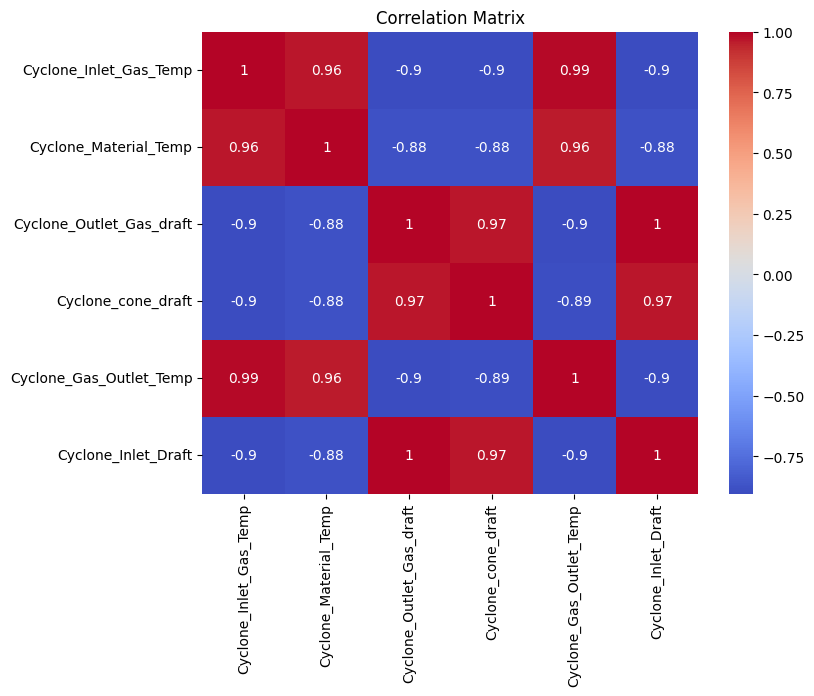

In [102]:
#CONVERTING STRING VALUES TO NUMERIC 

cols_to_convert = ['Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft',
                   'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

#CORELATION MATRIX  
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()    


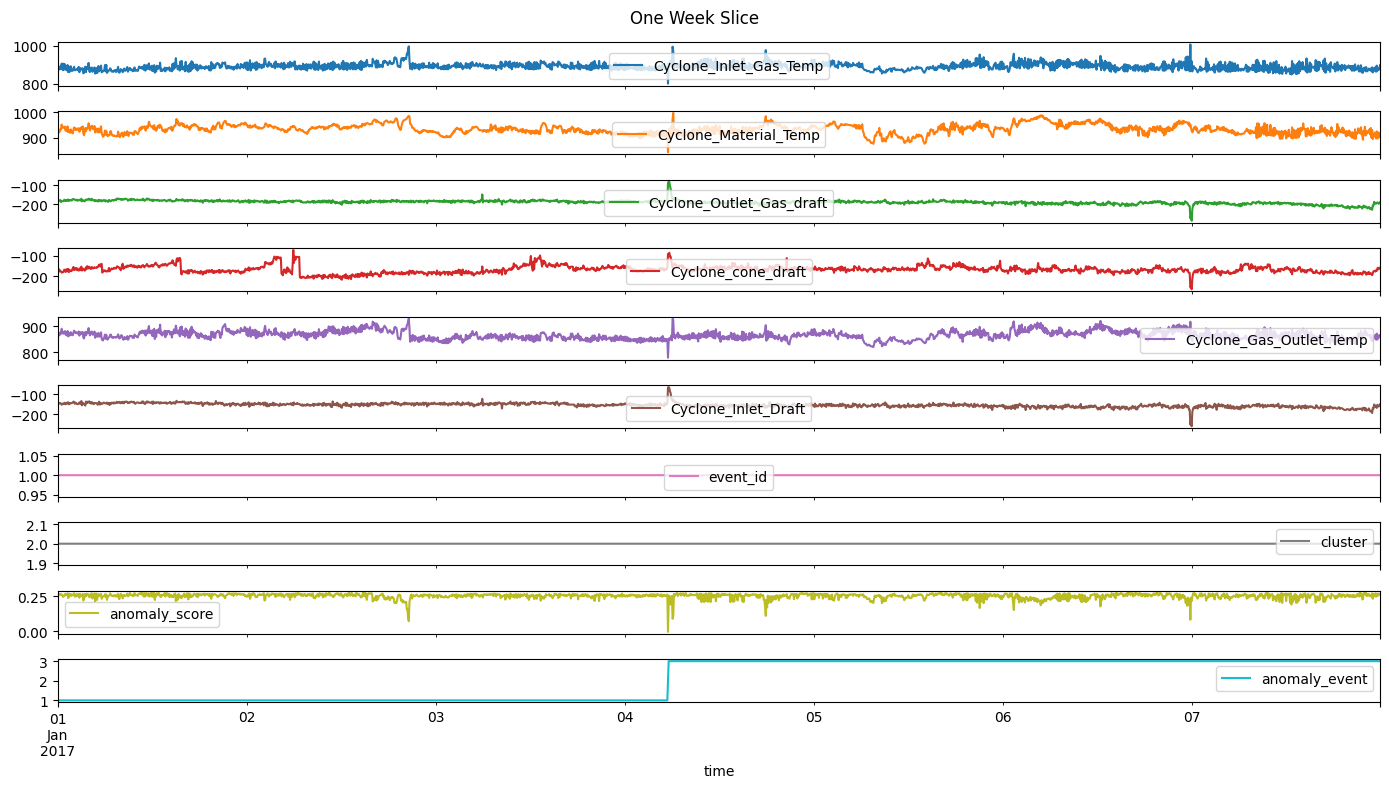

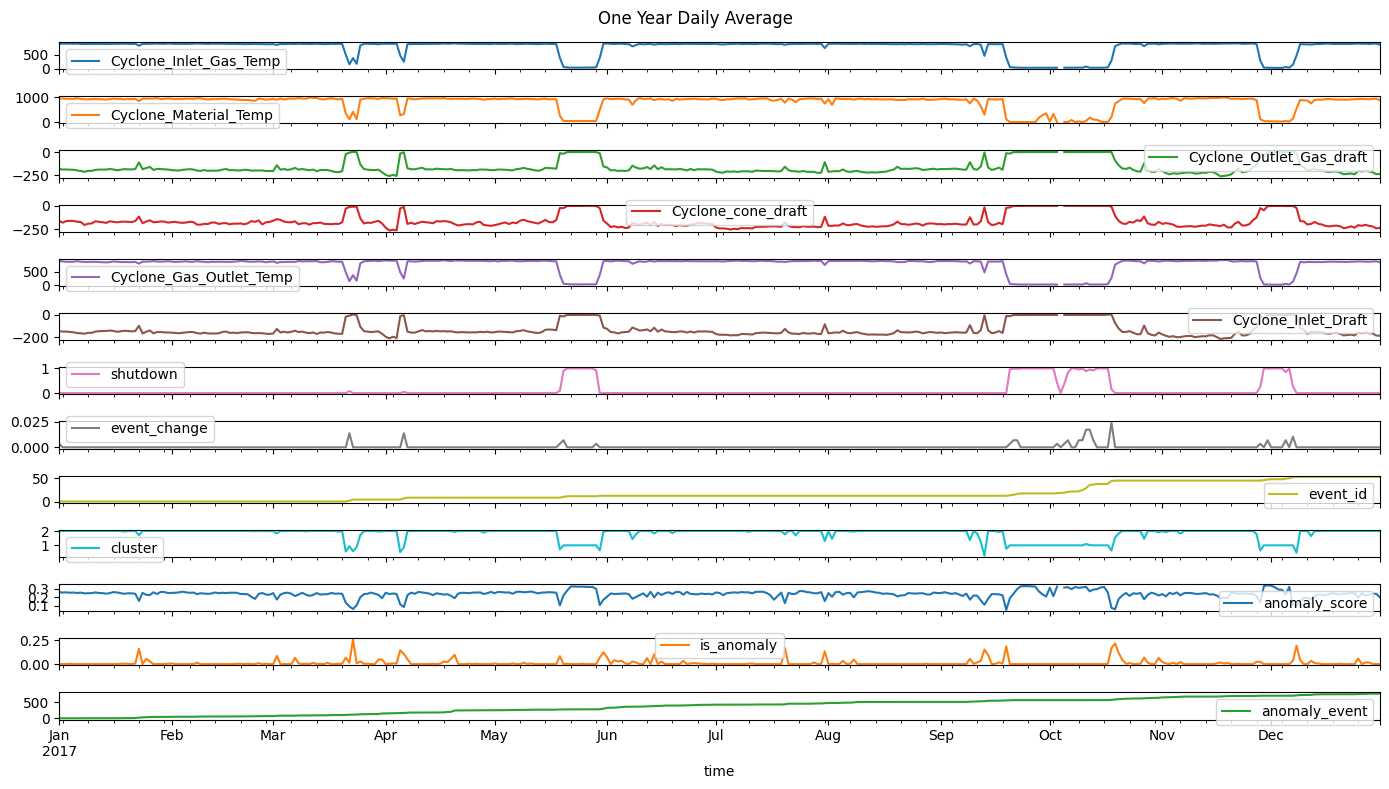

In [110]:
#VISUALIZATION 

# One week
week = df.iloc[:7*24*12]   # 7 days * 24h * 12 intervals (5 min each)
week.plot(subplots=True, figsize=(14,8), title="One Week Slice")
plt.tight_layout()
plt.show()

# One year 
year = df.resample("1D").mean().iloc[:365]
year.plot(subplots=True, figsize=(14,8), title="One Year Daily Average")
plt.tight_layout()
plt.show()

In [104]:
#CALCULATING MEAN, STANDARD DEVIATION and  Z-SCORE 


import pandas as pd
import matplotlib.pyplot as plt

df = df.copy()

# Selecting temperature columns
temp_cols = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Gas_Outlet_Temp",
    "Cyclone_Material_Temp"
]

thresholds = []

for col in temp_cols:
    mean = df[col].mean()
    std = df[col].std()
    lower_z = mean - 2 * std
    upper_z = mean + 2 * std
    lower_p = df[col].quantile(0.05)
    upper_p = df[col].quantile(0.95)

    thresholds.append({
        "Variable": col,
        "Mean": round(mean, 2),
        "Std Dev": round(std, 2),
        "Z-Score Lower": round(lower_z, 2),
        "Z-Score Upper": round(upper_z, 2),
        "5th Percentile": round(lower_p, 2),
        "95th Percentile": round(upper_p, 2)
    })

threshold_df = pd.DataFrame(thresholds)
print(threshold_df)



                  Variable    Mean  Std Dev  Z-Score Lower  Z-Score Upper  \
0   Cyclone_Inlet_Gas_Temp  727.70   328.37          70.95        1384.44   
1  Cyclone_Gas_Outlet_Temp  716.10   325.05          65.99        1366.21   
2    Cyclone_Material_Temp  751.17   350.60          49.98        1452.37   

   5th Percentile  95th Percentile  
0           30.19           934.02  
1           30.24           933.00  
2           20.46           985.75  


Total shutdown events (3 yrs): 62
Total downtime: 5146.00 hours
                       start                 end  duration_hours
event_id                                                        
2        2017-03-22 12:00:00 2017-03-22 12:45:00        0.750000
4        2017-03-22 15:55:00 2017-03-22 17:00:00        1.083333
6        2017-04-06 08:40:00 2017-04-06 08:50:00        0.166667
8        2017-04-06 10:00:00 2017-04-06 10:50:00        0.833333
10       2017-05-19 21:40:00 2017-05-20 13:05:00       15.416667
12       2017-05-20 15:25:00 2017-05-29 22:00:00      222.583333
14       2017-09-20 01:00:00 2017-09-21 11:40:00       34.666667
16       2017-09-21 11:55:00 2017-09-22 12:00:00       24.083333
18       2017-09-22 12:30:00 2017-10-03 09:55:00      261.416667
20       2017-10-05 14:50:00 2017-10-06 04:25:00       13.583333


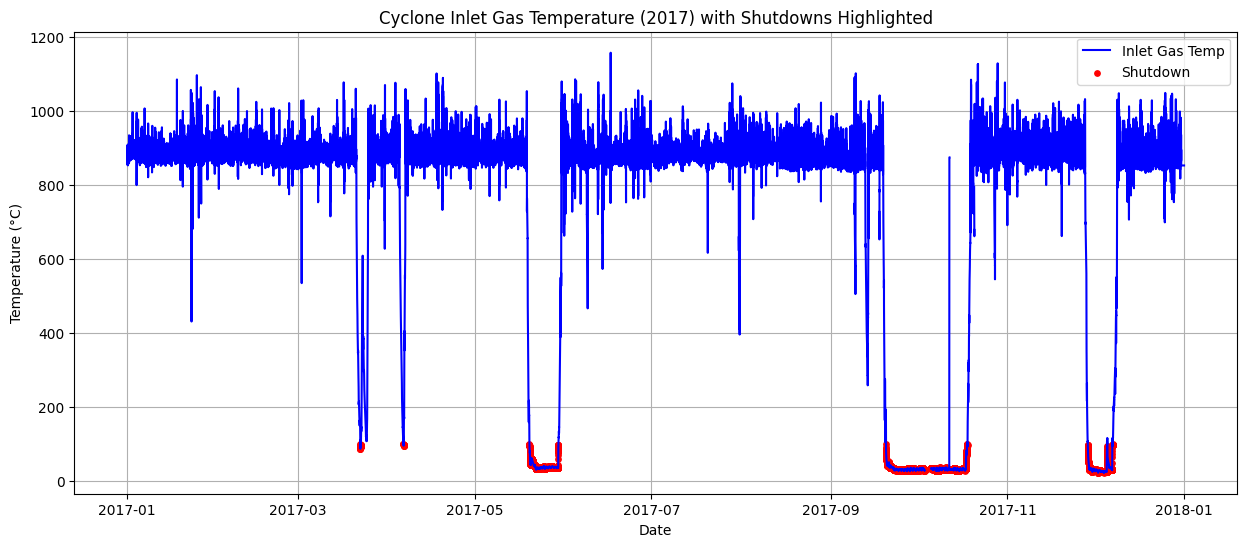

In [114]:
#SHUTDOWN DETECTION

THRESHOLD = 100  #since shuddown=low temperature using percentiles we can assume that threshold = 100 °C
df["shutdown"] = df["Cyclone_Inlet_Gas_Temp"] < THRESHOLD

df["event_change"] = df["shutdown"].ne(df["shutdown"].shift())
df["event_id"] = df["event_change"].cumsum()

#calculate total shutdown and total downtime
shutdowns = df[df["shutdown"]].groupby("event_id").agg(
    start=("shutdown", lambda x: x.index.min()),
    end=("shutdown", lambda x: x.index.max())
)
shutdowns["duration_hours"] = (shutdowns["end"] - shutdowns["start"]).dt.total_seconds() / 3600

total_shutdowns = len(shutdowns)
total_downtime_hours = shutdowns["duration_hours"].sum()

print(f"Total shutdown events (3 yrs): {total_shutdowns}")
print(f"Total downtime: {total_downtime_hours:.2f} hours")
print(shutdowns.head(10))
# Filter 1 year (e.g., 2017)
one_year = df.loc["2017"]

plt.figure(figsize=(15,6))
plt.plot(one_year.index, one_year["Cyclone_Inlet_Gas_Temp"], label="Inlet Gas Temp", color="blue")

# Highlight shutdowns as red dots
shutdown_points = one_year[one_year["shutdown"]]
plt.scatter(shutdown_points.index, shutdown_points["Cyclone_Inlet_Gas_Temp"],
            color="red", s=15, label="Shutdown")

plt.title("Cyclone Inlet Gas Temperature (2017) with Shutdowns Highlighted")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

Clustering complete! 4 states detected.

Cluster Summary Stats:


Cyclone_Inlet_Gas_Temp                              \
                          mean         std    min      max   
cluster                                                      
0.0                 888.067618   27.431004  100.0  1157.63   
1.0                 280.065841  121.855724  100.0   707.16   
2.0                 897.386524   24.725678  100.0  1135.63   
3.0                 653.612737  137.074153  100.0  1081.03   

        Cyclone_Gas_Outlet_Temp                               \
                           mean         std     min      max   
cluster                                                        
0.0                  877.345302   40.651232  210.49  1375.00   
1.0                  272.392610  122.069846   26.71   661.19   
2.0                  880.012002   55.159307  207.89  1375.00   
3.0                  636.020172  133.538928   70.78  1003.74   

        Cyclone_Material_Temp              ... Cyclone_Inlet_Draft          \
                         mean         std  ...                 min     max   
cluster                                    ...                               
0.0                918.817063   73.178335  ...             -233.41   -2.22   
1.0                163.045535  141.313667  ...              -74.02   32.78   
2.0                927.263418   65.652409  ...             -396.37 -148.87   
3.0                690.563383  238.732412  ...             -111.22   41.64   

        Cyclone_Outlet_Gas_draft                             \
                            mean        std     min     max   
cluster                                                       
0.0                  -198.679051  25.197254 -291.59    5.53   
1.0                     1.964728  12.532404  -97.39   38.11   
2.0                  -254.242319  20.249343 -456.66 -190.71   
3.0                    -1.255728  26.651455 -184.19   40.27   

        Cyclone_cone_draft                             
                      mean        std     min     max  
cluster                                                
0.0            -184.892955  28.006265 -261.40    3.70  
1.0              -6.937966  10.071689 -116.07   66.39  
2.0            -231.982582  23.642601 -459.31  -86.55  
3.0             -14.179554  25.771016 -200.87  488.86  

[4 rows x 24 columns]


Cluster Frequency & Duration:


,Occurrences,Total_Hours
cluster,,
0.0,142179,11848.250000
1.0,11567,963.916667
2.0,152458,12704.833333
3.0,9027,752.250000


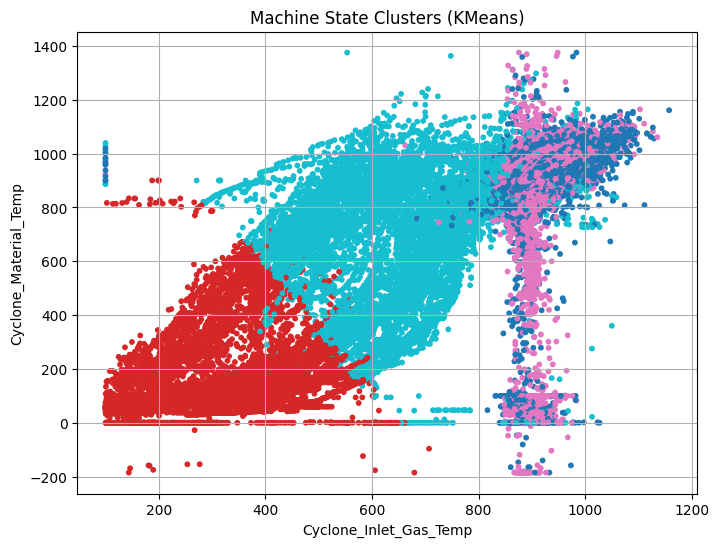


Cluster Interpretations:
Cluster 0: Normal Operation – Balanced temperature and pressure
Cluster 1: High Load – High inlet and material temperatures
Cluster 2: Degraded/Transition – Unstable draft or lower efficiency
Cluster 3: Startup/Shutdown – Transitional short bursts


In [106]:
# MACHINE STATE SEGMENTATION (CLUSTERING)

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


THRESHOLD = 100 
df["shutdown"] = df["Cyclone_Inlet_Gas_Temp"] < THRESHOLD
active_df = df[~df["shutdown"]].copy()   # keeping only active operation

# Select columns features for clustering
features = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Gas_Outlet_Temp",
    "Cyclone_Material_Temp",
    "Cyclone_Inlet_Draft",
    "Cyclone_Outlet_Gas_draft",
    "Cyclone_cone_draft"
]

X = active_df[features].dropna()

#clustering 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Applying simple KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
active_df.loc[X.index, "cluster"] = kmeans.fit_predict(X_scaled)


print("Clustering complete! 4 states detected.")

#cluster summary
summary = active_df.groupby("cluster")[features].agg(["mean", "std", "min", "max"])
print("\nCluster Summary Stats:")
display(summary)


# Count how many times each cluster appears
freq = active_df["cluster"].value_counts().sort_index()

# Approximate duration (since 5-minute interval)
duration_hours = freq * 5 / 60

cluster_stats = pd.DataFrame({
    "Occurrences": freq,
    "Total_Hours": duration_hours
})
print("\nCluster Frequency & Duration:")
display(cluster_stats)

#visualization
plt.figure(figsize=(8,6))
plt.scatter(
    active_df["Cyclone_Inlet_Gas_Temp"], 
    active_df["Cyclone_Material_Temp"],
    c=active_df["cluster"], cmap="tab10", s=10
)
plt.xlabel("Cyclone_Inlet_Gas_Temp")
plt.ylabel("Cyclone_Material_Temp")
plt.title("Machine State Clusters (KMeans)")
plt.grid(True)
plt.show()


interpretation = {
    0: "Normal Operation – Balanced temperature and pressure",
    1: "High Load – High inlet and material temperatures",
    2: "Degraded/Transition – Unstable draft or lower efficiency",
    3: "Startup/Shutdown – Transitional short bursts"
}

print("\nCluster Interpretations:")
for cid, desc in interpretation.items():
    print(f"Cluster {cid}: {desc}")


In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select main features
features = ["Cyclone_Inlet_Gas_Temp", "Cyclone_Gas_Outlet_Temp", "Cyclone_Material_Temp"]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features].fillna(method="ffill"))

# Simple KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(" Added simple 3-state cluster labels.")

 Added simple 3-state cluster labels.


Anomaly detection done per cluster!
Total anomalous events detected: 2021

 Anomaly 1350: 2018-04-24 01:45:00 → 2018-04-24 01:45:00  (Duration: 0.0 min)
   Avg values during anomaly: {'Cyclone_Inlet_Gas_Temp': 945.28, 'Cyclone_Gas_Outlet_Temp': 737.81, 'Cyclone_Material_Temp': 1038.52}
    Hypothesis: Minor fluctuation or transient disturbance.


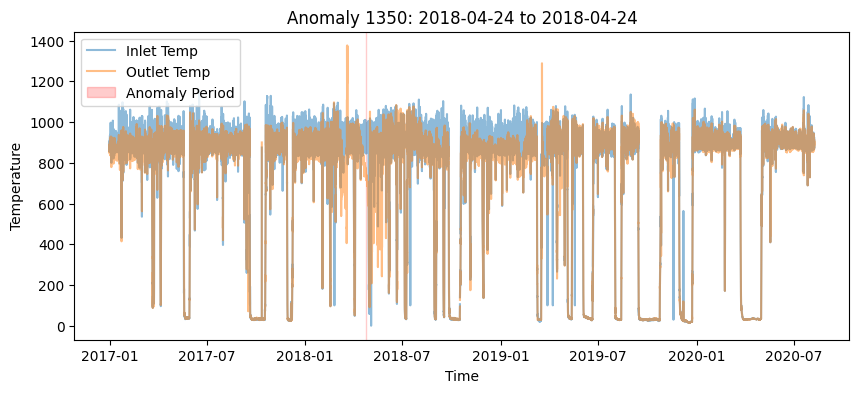


 Anomaly 2768: 2019-02-17 03:40:00 → 2019-02-17 03:40:00  (Duration: 0.0 min)
   Avg values during anomaly: {'Cyclone_Inlet_Gas_Temp': 823.95, 'Cyclone_Gas_Outlet_Temp': 784.68, 'Cyclone_Material_Temp': 826.07}
    Hypothesis: Minor fluctuation or transient disturbance.


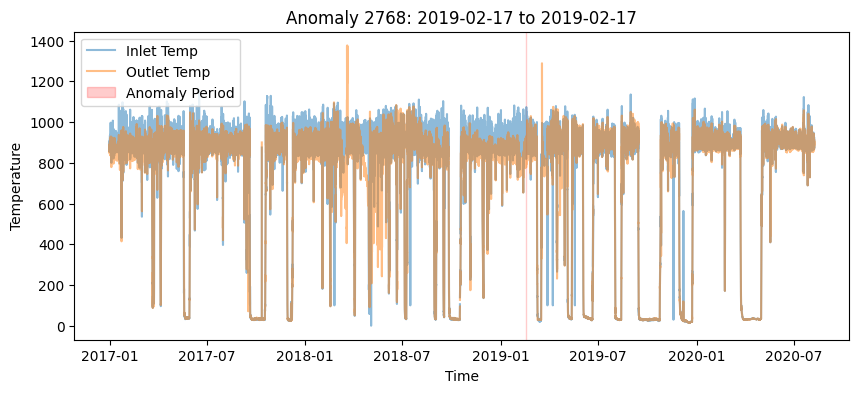


 Anomaly 1442: 2018-04-28 11:40:00 → 2018-04-28 11:40:00  (Duration: 0.0 min)
   Avg values during anomaly: {'Cyclone_Inlet_Gas_Temp': 895.94, 'Cyclone_Gas_Outlet_Temp': 595.96, 'Cyclone_Material_Temp': 859.37}
    Hypothesis: Minor fluctuation or transient disturbance.


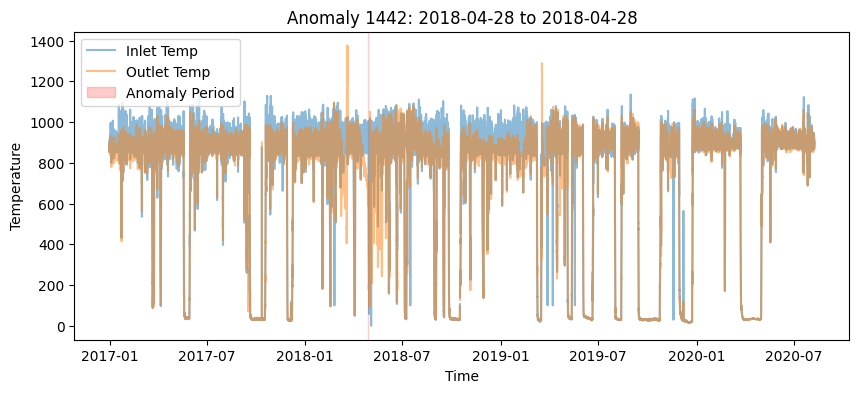

In [111]:
#ANAMOLY DETECTION AND ROOT CAUSE ANALYSIS
from sklearn.ensemble import IsolationForest

features = ["Cyclone_Inlet_Gas_Temp", "Cyclone_Gas_Outlet_Temp", "Cyclone_Material_Temp"]

# Store anomaly results
df["anomaly_score"] = np.nan
df["is_anomaly"] = False

for cl in sorted(df["cluster"].dropna().unique()):
    cluster_data = df[df["cluster"] == cl]
    X = cluster_data[features].dropna()
    if len(X) < 100:  # skip very small clusters
        continue
    
    model = IsolationForest(contamination=0.02, random_state=42)
    scores = model.fit_predict(X)
    
    df.loc[X.index, "anomaly_score"] = model.decision_function(X)
    df.loc[X.index, "is_anomaly"] = scores == -1  # -1 = anomaly

print("Anomaly detection done per cluster!")


#identify contiguous anomalous periods

df["anomaly_event"] = (df["is_anomaly"] != df["is_anomaly"].shift()).cumsum()
anomaly_events = (
    df[df["is_anomaly"]]
    .groupby("anomaly_event")
    .agg(start=("is_anomaly", "idxmin"),
         end=("is_anomaly", "idxmax"))
)
anomaly_events["duration_min"] = (anomaly_events["end"] - anomaly_events["start"]).dt.total_seconds() / 60
print("Total anomalous events detected:", len(anomaly_events))

#analyze anomalies
sample_anomalies = anomaly_events.sample(min(3, len(anomaly_events)), random_state=42)

for i, row in sample_anomalies.iterrows():
    start, end = row["start"], row["end"]
    seg = df.loc[start:end]
    
    print(f"\n Anomaly {i}: {start} → {end}  (Duration: {row['duration_min']:.1f} min)")
    mean_vals = seg[features].mean().to_dict()
    print("   Avg values during anomaly:", mean_vals)
    
    # Simple root-cause hypothesis example
    if mean_vals["Cyclone_Inlet_Gas_Temp"] < 500:
        print("    Hypothesis: Inlet gas temperature dropped — possible upstream cooling or flow loss.")
    elif mean_vals["Cyclone_Gas_Outlet_Temp"] > 900:
        print("    Hypothesis: Outlet temperature spike — potential sensor drift or combustion imbalance.")
    else:
        print("    Hypothesis: Minor fluctuation or transient disturbance.")
    
 #visualization
    plt.figure(figsize=(10, 4))
    plt.plot(df.index, df["Cyclone_Inlet_Gas_Temp"], label="Inlet Temp", alpha=0.5)
    plt.plot(df.index, df["Cyclone_Gas_Outlet_Temp"], label="Outlet Temp", alpha=0.5)
    plt.axvspan(start, end, color="red", alpha=0.2, label="Anomaly Period")
    plt.legend()
    plt.title(f"Anomaly {i}: {start.date()} to {end.date()}")
    plt.xlabel("Time")
    plt.ylabel("Temperature")
    plt.show()

Persistence → RMSE: 21.31  MAE: 12.45
ARIMA → RMSE: 22.64  MAE: 12.63


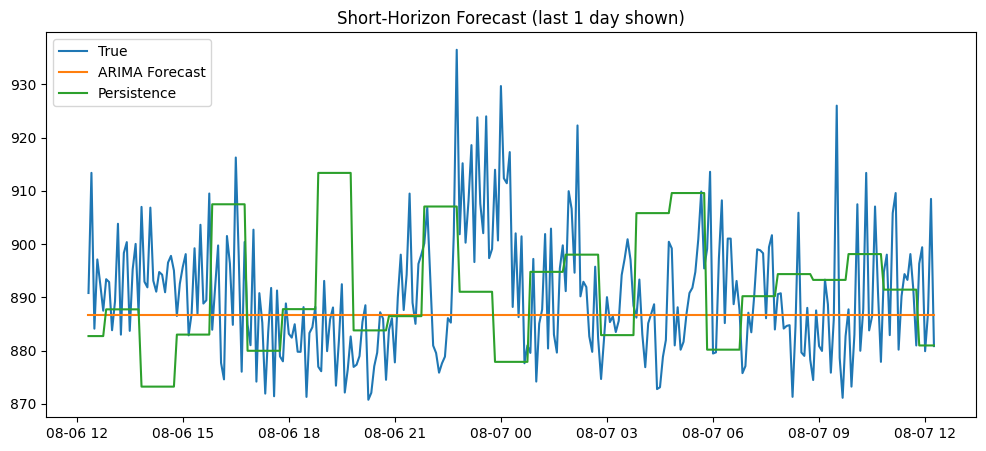

In [109]:
#SHORT HORIZON FORCASTING 


from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

#useing only active periods 
ts = active_df["Cyclone_Inlet_Gas_Temp"].dropna()


train = ts.iloc[:-12*24*30]   # train on history
test = ts.iloc[-12*24*30:]    # last month = test


y_true, y_pred_persistence = [], []
for i in range(12, len(test)):
    past = test.iloc[i-1]  # last observed value
    y_pred = [past] * 12   # predict 12 steps ahead
    y_true.append(test.iloc[i:i+12].values)
    y_pred_persistence.append(y_pred)

y_true = np.concatenate(y_true)[:len(y_pred_persistence)*12]
y_pred_persistence = np.concatenate(y_pred_persistence)[:len(y_true)]

# compute RMSE as sqrt of MSE 
rmse_persistence = np.sqrt(mean_squared_error(y_true, y_pred_persistence))
mae_persistence = mean_absolute_error(y_true, y_pred_persistence)

print("Persistence → RMSE:", round(rmse_persistence,2), " MAE:", round(mae_persistence,2))

#ARIMA model
model = ARIMA(train, order=(2,1,2)) 
fit = model.fit()

forecast = fit.forecast(steps=len(test))

#RMSE via sqrt
rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mae_arima = mean_absolute_error(test, forecast)

print("ARIMA → RMSE:", round(rmse_arima,2), " MAE:", round(mae_arima,2))

#compare visually (last one day)
plt.figure(figsize=(12,5))
plt.plot(test.index[-12*24:], test.values[-12*24:], label="True")
plt.plot(test.index[-12*24:], forecast[-12*24:], label="ARIMA Forecast")
plt.plot(test.index[-12*24:], y_pred_persistence[-12*24:], label="Persistence")
plt.title("Short-Horizon Forecast (last 1 day shown)")
plt.legend()
plt.show()
